<hr>
<center>
Національний технічний університет України <br>
"Київський політехнічний інститут імені Ігоря Сікорського" <br>
Факультет інформатики та обчислювальної техніки<br>
Кафедра інформаційних систем та технологій<br>
<br><br>
<b><i>Комп’ютерний практикум №x</i></b>  <br>
<i>з дисципліни </i>  <br>
<i>«Штучний інтелект в задачах обробки зображень» </i>  <br>
на тему <br>
«Виявлення об’єктів засобами OpenCV»  <br>
<br>
Виконали: студенти гр. ІО-34 Рибачок М.В. та Токарюк С.Б. <br>
Викладач: асистент Тюляков Д.І.<br>
<br> <br>
Київ - 2026
</center>
<hr>

## 1. Мета роботи

Навчитись виявляти обличчя, котячі мордашки та пішоходів з
використанням каскадів Хаара бібліотеки OpenCV

In [ ]:
2-3

## 4. Виконання роботи

In [4]:
# Завантаження потрібних бібліотек
import cv2, os
from deepface import DeepFace
import matplotlib.pyplot as plt

2026-03-16 13:05:51.569130: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-16 13:05:51.569354: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-16 13:05:51.612334: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-16 13:05:52.761362: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

In [17]:
# Функція для відображення зображень у Jupyter
def show_img(img, title="Image"):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 6))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(title)
    plt.show()

In [18]:
# Ініціалізація основного класифікатора для облич
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

### 1. Виявлення обличчя на фото
Алгоритм Віоли-Джонса розроблявся для виявлення облич на фото.

Знайдено осіб: 1


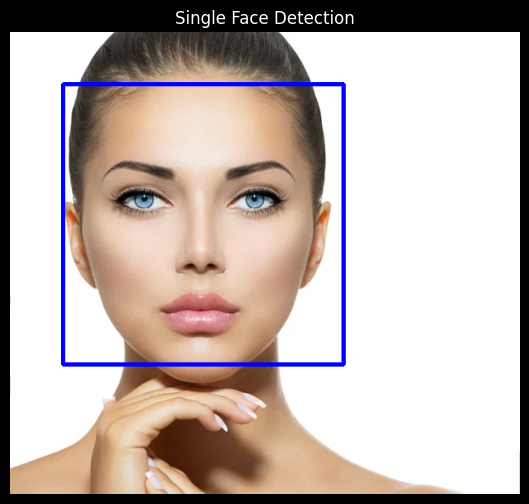

In [19]:
# Читання зображення (тут має бути фото з одним обличчям)
img_single = cv2.imread('/home/mishanya/PycharmProjects/AI_Computer_Vision/Lab_1/photos/singlePhoto.jpg')
gray_single = cv2.cvtColor(img_single, cv2.COLOR_BGR2GRAY)

# Виявлення облич
faces_single = face_cascade.detectMultiScale(gray_single, scaleFactor=1.3, minNeighbors=5)

print(f"Знайдено осіб: {len(faces_single)}")

for (x, y, w, h) in faces_single:
    cv2.rectangle(img_single, (x, y), (x+w, y+h), (255, 0, 0), 3)

show_img(img_single, "Single Face Detection")

### 2. Виявлення багатьох облич на фото
Цей класифікатор може виявити також і багато облич на фото і підрахувати їх кількість.

Кількість знайдених осіб на фото: 23


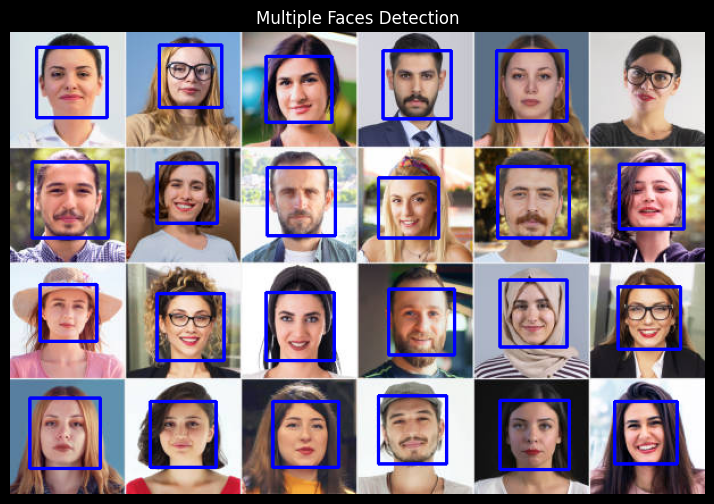

In [20]:
# Читання групового фото
img_multi = cv2.imread('/home/mishanya/PycharmProjects/AI_Computer_Vision/Lab_1/photos/groupPhoto.jpg')
gray_multi = cv2.cvtColor(img_multi, cv2.COLOR_BGR2GRAY)

# Для багатьох облич іноді потрібно підкрутити параметри
faces_multi = face_cascade.detectMultiScale(gray_multi, scaleFactor=1.1, minNeighbors=5)

print(f"Кількість знайдених осіб на фото: {len(faces_multi)}")

for (x, y, w, h) in faces_multi:
    cv2.rectangle(img_multi, (x, y), (x+w, y+h), (255, 0, 0), 2)

show_img(img_multi, "Multiple Faces Detection")

### 3. Виявлення обличчя, усмішки, очей людей
Це завдання виконує виявлення ключових рис обличчя за допомогою класифікаторів Хаара.

Знайдено осіб: 1


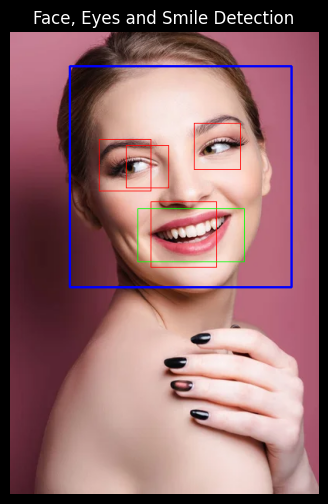

In [40]:
# Завантаження додаткових каскадів
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')
smile_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_smile.xml')

# Читання зображення для детального аналізу
img_features = cv2.imread('/home/mishanya/PycharmProjects/AI_Computer_Vision/Lab_1/photos/Photo3FaceSmiling.jpg')
# img_features = cv2.imread('/home/mishanya/PycharmProjects/AI_Computer_Vision/Lab_1/photos/myPhoto.jpg')
# img_features = cv2.imread('/home/mishanya/PycharmProjects/AI_Computer_Vision/Lab_1/photos/myPhoto0.jpg')
# img_features = cv2.imread('/home/mishanya/PycharmProjects/AI_Computer_Vision/Lab_1/photos/myPhoto2.jpg.jpg')

gray_features = cv2.cvtColor(img_features, cv2.COLOR_BGR2GRAY)

faces_features = face_cascade.detectMultiScale(gray_features, 1.1, 5)

print(f"Знайдено осіб: {len(faces_features)}")

for (x, y, w, h) in faces_features:
    # Малюємо синій прямокутник навколо обличчя
    cv2.rectangle(img_features, (x, y), (x+w, y+h), (255, 0, 0), 2)

    # Вирізаємо область обличчя для подальшого пошуку в ній
    roi_gray = gray_features[y:y+h, x:x+w]
    roi_color = img_features[y:y+h, x:x+w]

    # Виявлення очей
    eyes = eye_cascade.detectMultiScale(roi_gray)
    for (ex, ey, ew, eh) in eyes:
        cv2.rectangle(roi_color, (ex, ey), (ex+ew, ey+eh), (0, 0, 255), 1)

    # Виявлення усмішки
    smiles = smile_cascade.detectMultiScale(roi_gray, 1.4, 20)
    for (sx, sy, sw, sh) in smiles:
        cv2.rectangle(roi_color, (sx, sy), (sx+sw, sy+sh), (0, 255, 0), 1)

show_img(img_features, "Face, Eyes and Smile Detection")

### 4. Виявлення пішоходів на відео (HOG-класифікатор)
Використовуємо гістограму орієнтованих градієнтів (HOG) для детекції людей.

Знайдено котиків: 3


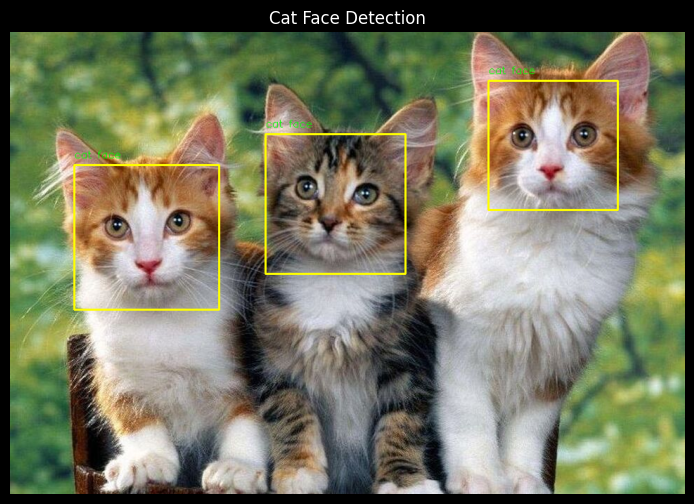

In [15]:
cat_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalcatface.xml'
)

# Завантаження зображення
img = cv2.imread('/home/mishanya/PycharmProjects/AI_Computer_Vision/Lab_1/photos/catsPhoto.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Виявлення котячих мордочок
faces = cat_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=7)
print(f"Знайдено котиків: {len(faces)}")

for (x, y, w, h) in faces:
    cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 255), 2)
    cv2.putText(img, "cat face", (x, y - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

show_img(img, "Cat Face Detection")

### 4. Розпізнавання котячих мордашок:

In [27]:
# Ініціалізація HOG детектора
hog = cv2.HOGDescriptor()
hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())

# Відкриття відео (замініть на ваше відео або 0 для веб-камери)
cap = cv2.VideoCapture('/home/mishanya/PycharmProjects/AI_Computer_Vision/Lab_1/video/peopleWalkingVideo.mp4')

while cap.isOpened():
    ret, frame = cap.read()
    if not ret: break

    frame = cv2.resize(frame, (800, 568))

    # Детекція людей
    boxes, weights = hog.detectMultiScale(frame, winStride=(8, 8), padding=(30, 30), scale=1.06)

    for (x, y, w, h) in boxes:
        cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 255), 2)

    cv2.imshow('Pedestrian Detection', frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

### 6. Розпізнавання статі та емоцій людей:

## Висновок:
івавіаівав

     Підготували: Рибачок Махайло та Токарюк Станіслав